In [ ]:
# All paths in this notebook are relative to the repository root; anchor the working directory there
import os
while not os.path.exists('METHODOLOGY.md') and os.getcwd() != '/': os.chdir('..')
assert os.path.exists('METHODOLOGY.md'), 'run from inside the Nofit_LRT_Extension repository'

# MSSIM Tests — THS Survey vs Cellular vs Hybrid

The **structural similarity index** (SSIM, Wang et al. 2004) compares two images window by window on three terms — luminance (local means), contrast (local standard deviations) and structure (local correlation) — and MSSIM is its mean over all windows. Djukic, van Lint & Hoogendoorn (2013) proposed it for OD matrices because, unlike a cell-wise error, it rewards a matrix that gets the *neighbourhood* right: trips shifted to an adjacent zone cost little, trips moved across the region cost a lot. For that to hold, neighbouring rows and columns must be spatial neighbours, so the **zone ordering** is part of the test design.

$$\mathrm{SSIM}(x, y) = \underbrace{\frac{2\mu_x\mu_y + C_1}{\mu_x^2 + \mu_y^2 + C_1}}_{\text{luminance}} \cdot \underbrace{\frac{2\sigma_x\sigma_y + C_2}{\sigma_x^2 + \sigma_y^2 + C_2}}_{\text{contrast}} \cdot \underbrace{\frac{\sigma_{xy} + C_2/2}{\sigma_x\sigma_y + C_2/2}}_{\text{structure}}, \qquad C_1 = (0.01 L)^2,\ C_2 = (0.03 L)^2$$

with $L$ the dynamic range (the larger of the two matrices' maxima).

| # | Test | Design |
|---|---|---|
| M1 | MSSIM by window size | TAZ (778) windows 5 / 9 / 15 / 25, superzone (36) windows 3 / 5, 28 sub-areas window 3; raw trips (Djukic-standard) and log(1 + trips) (OD values span five orders of magnitude, so the raw index is driven by the few largest cells) |
| M2 | Zone ordering and chance level | Hilbert-curve order of centroids (primary) vs native TAZ numbering vs a random ordering applied to both matrices (ordering sensitivity); the chance level is a **broken-correspondence null** — one matrix's zones permuted, the other kept — which destroys the geography of the comparison while keeping every window's composition |
| M3 | Term decomposition | mean luminance / contrast / structure terms; MSSIM on windows away from the diagonal |
| M4 | Local SSIM maps | where the matrices agree: TAZ-level maps, superzone-block means, per-origin means, corridor classes |

Matrices are the same three as in the cosine / GEH and KS notebooks: the **THS survey rebuilt from the trips file (survey days 1 and 2)** — the activities file (days 10 / 20) is not read —, the **cellular** AM matrix allocated total-preservingly to study TAZs and scaled to the survey total (SSIM's luminance term is scale-sensitive; a row-matched variant is a sensitivity), and the **primary hybrid**. References: survey day 1 vs day 2 (ceiling) and the broken-correspondence null (chance).

In [1]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.colors import LinearSegmentedColormap
from scipy.ndimage import uniform_filter
import shapefile
from shapely.geometry import shape

rng = np.random.default_rng(42)
BLUE, ORANGE, AQUA, PURPLE = '#2a78d6', '#eb6834', '#1baf7a', '#7b5bd6'
INK, INK2, MUTED, GRID, AXIS = '#0b0b0b', '#52514e', '#898781', '#e1e0d9', '#c3c2b7'
CMAP_DIV = LinearSegmentedColormap.from_list('div', ['#7f1e1e', '#e34948', '#f2a29e', '#f0efec', '#86b6ef', '#2a78d6', '#0d366b'])
CMAP_SEQ = LinearSegmentedColormap.from_list('seq_blue', ['#fcfcfb', '#cde2fb', '#9ec5f4', '#6da7ec', '#3987e5', '#256abf', '#184f95', '#0d366b'])

def style_ax(ax, title=None, xlabel=None, ylabel=None):
    ax.grid(True, color=GRID, linewidth=0.6); ax.set_axisbelow(True)
    for s in ax.spines.values(): s.set_color(AXIS)
    ax.tick_params(colors=INK2, labelsize=9)
    if title: ax.set_title(title, color=INK, fontsize=12)
    if xlabel: ax.set_xlabel(xlabel, color=INK2, fontsize=10)
    if ylabel: ax.set_ylabel(ylabel, color=INK2, fontsize=10)

OUT = 'Output/ths2017/tests'
os.makedirs(OUT, exist_ok=True); os.makedirs('Output/figures', exist_ok=True)
def save_show(fig, name):
    fig.savefig(f'Output/figures/{name}', dpi=150, bbox_inches='tight', facecolor='white'); plt.show()

## 1. Data — the same chain as the cosine / GEH and KS notebooks

In [2]:
TRIPS_FILE = 'Input/THS_2017-2018/trips_ths_2017.xlsx'
df = pd.read_excel(TRIPS_FILE)
assert set(df['SurveyDay'].unique()) == {1, 2}, "the trips file must carry survey days 1 and 2 only"
d = df.sort_values(['PerID3', 'SurveyDay', 'placeno']).copy()
g = d.groupby(['PerID3', 'SurveyDay'])
d['origin'] = g['actTaz'].shift(1); d['trip_dep_h'] = g['Dep_h'].shift(1)
trips = d.dropna(subset=['origin', 'actTaz', 'trip_dep_h'])
trips = trips[trips['trip_dep_h'].isin([6, 7, 8])]
k26 = pd.read_excel('Input/TAZ_2636_Keys.xlsx').drop_duplicates('TAZ_2636')
map_2636_1250 = k26.set_index('TAZ_2636')['TAZ_1250']
trips = trips.assign(o1250=trips['origin'].map(map_2636_1250), d1250=trips['actTaz'].map(map_2636_1250))

keys_raw = pd.read_csv('Input/Matrices/1270_02_09_2021_TAZ_North_keys.csv', encoding='windows-1255')
kn = keys_raw[['TAZ_1270', 'TAZ_NUMBER']].dropna(subset=['TAZ_NUMBER']); kn['TAZ_NUMBER'] = kn['TAZ_NUMBER'].astype(int)
kd = kn.drop_duplicates('TAZ_NUMBER')
cellular = pd.read_csv('Input/Matrices/AvgDayHourlyTrips201819_1270_weekday_v1.csv')[['fromZone', 'ToZone', 'h6', 'h7', 'h8']]
c = cellular.merge(kd.rename(columns={'TAZ_1270': 'fromZone', 'TAZ_NUMBER': 'fromTaz'}), on='fromZone')
c = c.merge(kd.rename(columns={'TAZ_1270': 'ToZone', 'TAZ_NUMBER': 'ToTaz'}), on='ToZone')
cell_taz_repl = c.groupby(['fromTaz', 'ToTaz'])[['h6', 'h7', 'h8']].sum().sum(axis=1).unstack().fillna(0)
TAZ = cell_taz_repl.index; N = len(TAZ)
out_vol, in_vol = cell_taz_repl.sum(axis=1), cell_taz_repl.sum(axis=0)
north_1250 = sorted(kd[kd['TAZ_NUMBER'].isin(TAZ)]['TAZ_1270'].unique())
z_idx = {z: i for i, z in enumerate(north_1250)}
children = kd[kd['TAZ_NUMBER'].isin(TAZ)].groupby('TAZ_1270')['TAZ_NUMBER'].apply(list)
taz_pos = {t: j for j, t in enumerate(TAZ)}
def alloc_matrix(vol):
    S = np.zeros((len(north_1250), N))
    for z, kids in children.items():
        v = np.array([vol[t] for t in kids], float)
        s = v / v.sum() if v.sum() > 0 else np.full(len(kids), 1 / len(kids))
        for t, sh in zip(kids, s): S[z_idx[z], taz_pos[t]] = sh
    return S
S_o, S_d = alloc_matrix(out_vol), alloc_matrix(in_vol)
tm = trips[trips['o1250'].isin(z_idx) & trips['d1250'].isin(z_idx)].copy()
tm['oi'] = tm['o1250'].map(z_idx); tm['di'] = tm['d1250'].map(z_idx)
def survey_1250(t):
    M = np.zeros((len(north_1250), len(north_1250))); np.add.at(M, (t['oi'].values, t['di'].values), t['new_wf'].values); return M
S1 = S_o.T @ survey_1250(tm[tm['SurveyDay'] == 1]) @ S_d
S2 = S_o.T @ survey_1250(tm[tm['SurveyDay'] == 2]) @ S_d
SAVG = (S1 + S2) / 2
saved_avg = pd.read_csv('Output/ths2017/study_taz/matrix_avg_ALL_taz.csv', index_col=0); saved_avg.columns = saved_avg.columns.astype(int)
assert np.abs(SAVG - saved_avg.reindex(index=TAZ, columns=TAZ).values).max() / saved_avg.values.max() < 1e-4
print("validation: rebuilt trips-file day-average matches saved matrix_avg_ALL_taz.csv")

cn = cellular[cellular['fromZone'].isin(z_idx) & cellular['ToZone'].isin(z_idx)]
C_1250 = (cn.assign(v=cn[['h6', 'h7', 'h8']].sum(axis=1)).groupby(['fromZone', 'ToZone'])['v'].sum()
          .unstack().reindex(index=north_1250, columns=north_1250, fill_value=0).fillna(0).values)
C_raw = S_o.T @ C_1250 @ S_d
C = C_raw * SAVG.sum() / C_raw.sum()                                            # scaled to the survey total
rs = C_raw.sum(axis=1, keepdims=True)
C_row = np.where(rs > 0, C_raw / np.where(rs == 0, 1, rs), 0) * SAVG.sum(axis=1, keepdims=True)   # row-matched sensitivity
def load_sq(path):
    m = pd.read_csv(path, index_col=0)
    m.index = m.index.astype(float).astype(int); m.columns = m.columns.astype(float).astype(int)
    return m.reindex(index=TAZ, columns=TAZ).fillna(0).values
H = load_sq('Output/ths2017/study_taz/hybrid_taz_trips.csv')
H_gs = load_sq('Output/ths2017/study_taz/hybrid_taz_trips_gs.csv')

taz_to_sz = keys_raw[['TAZ_NUMBER', 'SZ_NEW']].dropna().astype(int).drop_duplicates('TAZ_NUMBER').set_index('TAZ_NUMBER')['SZ_NEW']
sub_key = pd.read_excel('Input/Submatrix_tazs.xlsx')
taz_to_area = sub_key.set_index('TAZ')['AggAreaCode']
corridor = np.array([t in set(sub_key.loc[sub_key['IsLRT_Corridor'] == 1, 'TAZ']) for t in TAZ])
sz_of = np.array([taz_to_sz[t] for t in TAZ]); SZ = sorted(set(sz_of))
corr_sz = sorted({taz_to_sz[t] for t, f in zip(TAZ, corridor) if f})

sf = shapefile.Reader('Input/TAZ_North/TAZ_North.shp')
cent = {sr.record['TAZ_NUMBER']: shape(sr.shape.__geo_interface__).centroid for sr in sf.shapeRecords()}
xy = np.array([(cent[t].x, cent[t].y) for t in TAZ])
print(f"survey d1 {S1.sum():,.0f} / d2 {S2.sum():,.0f} / avg {SAVG.sum():,.0f}; cellular (scaled) {C.sum():,.0f}; hybrid {H.sum():,.0f}; "
      f"{corridor.sum()} corridor TAZs in {len(corr_sz)} superzones")

validation: rebuilt trips-file day-average matches saved matrix_avg_ALL_taz.csv


survey d1 2,077,302 / d2 2,059,015 / avg 2,068,158; cellular (scaled) 2,068,158; hybrid 2,068,158; 119 corridor TAZs in 15 superzones


### 1b. Zone orderings

- **Hilbert** (primary): TAZ centroids on a Hilbert curve (order 12 over the study bounding box), so rows / columns that are adjacent in the matrix are close in space, and each superzone's TAZs end up largely contiguous.
- **Native**: the study TAZ numbering (grouped by municipality / superzone, but not spatially ordered within).
- **Random (both)**: one random permutation applied to both matrices — an ordering sensitivity, *not* a chance level (the cell correspondence is intact).
- **Null**: the un-permuted matrix in Hilbert order against the other matrix with its zones permuted — the correspondence is broken, so this is what MSSIM reads when the two matrices share nothing but their value distributions.

Superzones and sub-areas are ordered by the Hilbert index of their centroids.

In [3]:
def hilbert_index(x, y, order=12):
    """xy in [0, 2^order) integer grid -> Hilbert curve distance (Wikipedia xy2d)"""
    n = 1 << order
    dist = np.zeros(len(x), dtype=np.int64)
    x, y = x.astype(np.int64).copy(), y.astype(np.int64).copy()
    s = n >> 1
    while s > 0:
        rx = ((x & s) > 0).astype(np.int64); ry = ((y & s) > 0).astype(np.int64)
        dist += s * s * ((3 * rx) ^ ry)
        # rotate
        flip = ry == 0
        swap = flip & (rx == 1)
        x[swap], y[swap] = (s - 1 - x[swap]), (s - 1 - y[swap])
        x[flip], y[flip] = y[flip].copy(), x[flip].copy()
        s >>= 1
    return dist

def hilbert_order(pts, order=12):
    lo, hi = pts.min(axis=0), pts.max(axis=0)
    scale = ((1 << order) - 1) / (hi - lo).max()
    grid = np.floor((pts - lo) * scale).astype(np.int64)
    return np.argsort(hilbert_index(grid[:, 0], grid[:, 1], order), kind='stable')

ORD = {'hilbert': hilbert_order(xy), 'native': np.arange(N)}
# how contiguous are superzones under each ordering? (share of adjacent row pairs in the same superzone)
for k, o in ORD.items():
    print(f"{k:>8} order: {np.mean(sz_of[o][1:] == sz_of[o][:-1]):.0%} of adjacent TAZ pairs share a superzone; "
          f"median centroid distance between adjacent rows {np.median(np.linalg.norm(xy[o][1:] - xy[o][:-1], axis=1)) / 1000:.1f} km")
o = rng.permutation(N)
print(f"  random order: {np.mean(sz_of[o][1:] == sz_of[o][:-1]):.0%}; median adjacent distance {np.median(np.linalg.norm(xy[o][1:] - xy[o][:-1], axis=1)) / 1000:.1f} km")

# aggregation to superzones and sub-areas, ordered by Hilbert index of zone centroids
def indicator(labels):
    zones = sorted(set(l for l in labels if l == l)); pos = {z: i for i, z in enumerate(zones)}
    M = np.zeros((N, len(zones)))
    for j, l in enumerate(labels):
        if l == l: M[j, pos[l]] = 1
    return zones, M
area_of = np.array([taz_to_area.get(t, np.nan) for t in TAZ])
SZ, M_sz = indicator(sz_of); AREA, M_area = indicator(area_of)
def zone_order(M):
    cz = (M.T @ xy) / M.sum(axis=0)[:, None]
    return hilbert_order(cz)
ORD_SZ, ORD_AREA = zone_order(M_sz), zone_order(M_area)

 hilbert order: 77% of adjacent TAZ pairs share a superzone; median centroid distance between adjacent rows 1.4 km
  native order: 95% of adjacent TAZ pairs share a superzone; median centroid distance between adjacent rows 1.7 km
  random order: 3%; median adjacent distance 29.0 km


## 2. SSIM machinery

Sliding square windows (uniform filter, stride 1, border-cropped to full windows), $C_1 = (0.01L)^2$, $C_2 = (0.03L)^2$ with $L$ = max of the two matrices. Each window yields luminance, contrast and structure terms; SSIM is their product and MSSIM the mean over windows. The "off-diagonal" MSSIM averages only windows whose centre lies more than half a window from the diagonal.

In [4]:
def ssim_terms(A, B, w, L=None):
    A, B = np.asarray(A, float), np.asarray(B, float)
    L = max(A.max(), B.max()) if L is None else L
    C1, C2 = (0.01 * L) ** 2, (0.03 * L) ** 2
    f = lambda X: uniform_filter(X, size=w, mode='reflect')
    mu_a, mu_b = f(A), f(B)
    va = np.maximum(f(A * A) - mu_a ** 2, 0); vb = np.maximum(f(B * B) - mu_b ** 2, 0); cov = f(A * B) - mu_a * mu_b
    sa, sb = np.sqrt(va), np.sqrt(vb)
    lum = (2 * mu_a * mu_b + C1) / (mu_a ** 2 + mu_b ** 2 + C1)
    con = (2 * sa * sb + C2) / (va + vb + C2)
    stru = (cov + C2 / 2) / (sa * sb + C2 / 2)
    h = w // 2
    sl = slice(h, A.shape[0] - h) if h > 0 else slice(None)
    return {'lum': lum[sl, sl], 'con': con[sl, sl], 'str': stru[sl, sl], 'ssim': (lum * con * stru)[sl, sl]}

def reorder(X, o): return X[np.ix_(o, o)]

def mssim(A, B, w, o=None, transform=None):
    if o is not None: A, B = reorder(A, o), reorder(B, o)
    if transform == 'log': A, B = np.log1p(A), np.log1p(B)
    t = ssim_terms(A, B, w)
    n = t['ssim'].shape[0]; h = w // 2
    ii, jj = np.indices((n, n)); off = np.abs(ii - jj) > h          # window centre at least h+1 from the diagonal (in cropped coords the diagonal is preserved)
    return {'MSSIM': float(t['ssim'].mean()), 'luminance': float(t['lum'].mean()), 'contrast': float(t['con'].mean()),
            'structure': float(t['str'].mean()), 'MSSIM off-diag': float(t['ssim'][off].mean()), 'windows': int(n * n)}

## M1–M3. MSSIM by window size, ordering and scale, with term decomposition

In [5]:
SRC_TAZ = {'survey d1': S1, 'survey d2': S2, 'survey avg': SAVG, 'cellular': C, 'cellular (row-matched)': C_row, 'hybrid': H, 'hybrid (GS-cal.)': H_gs}
PAIRS = [('survey d1', 'survey d2'), ('survey avg', 'cellular'), ('hybrid', 'cellular'), ('hybrid', 'survey avg'),
         ('survey avg', 'cellular (row-matched)'), ('hybrid', 'cellular (row-matched)'), ('hybrid (GS-cal.)', 'cellular'), ('hybrid (GS-cal.)', 'survey avg')]
SETUPS = [('TAZ', SRC_TAZ, [5, 9, 15, 25], ORD['hilbert'], ORD['native']),
          ('SZ', {k: M_sz.T @ v @ M_sz for k, v in SRC_TAZ.items()}, [3, 5], ORD_SZ, np.arange(len(SZ))),
          ('AREA', {k: M_area.T @ v @ M_area for k, v in SRC_TAZ.items()}, [3], ORD_AREA, np.arange(len(AREA)))]

rows = []
for lvl, S, windows, o_h, o_n in SETUPS:
    for w in windows:
        for tr in ['raw', 'log']:
            for oname, o in [('hilbert', o_h), ('native', o_n)]:
                for a, b in PAIRS:
                    rows.append({'level': lvl, 'window': w, 'scale': tr, 'order': oname, 'pair': f'{a} vs {b}', **mssim(S[a], S[b], w, o, tr)})
            n_rep = 20 if lvl == 'TAZ' else 40
            for a, b in [('survey d1', 'survey d2'), ('survey avg', 'cellular'), ('hybrid', 'cellular'), ('hybrid', 'survey avg')]:
                # ordering sensitivity: one random permutation applied to both matrices (correspondence intact)
                vals = [mssim(S[a], S[b], w, rng.permutation(S[a].shape[0]), tr)['MSSIM'] for _ in range(n_rep)]
                rows.append({'level': lvl, 'window': w, 'scale': tr, 'order': 'random (both)', 'pair': f'{a} vs {b}', 'MSSIM': float(np.mean(vals))})
                # chance level: A in Hilbert order, B's zones permuted (correspondence broken)
                nul = []
                for _ in range(n_rep):
                    pz = rng.permutation(S[a].shape[0])
                    nul.append(mssim(reorder(S[a], o_h), reorder(reorder(S[b], pz), o_h), w, None, tr)['MSSIM'])
                rows.append({'level': lvl, 'window': w, 'scale': tr, 'order': 'null (B permuted)', 'pair': f'{a} vs {b}', 'MSSIM': float(np.mean(nul)),
                             'MSSIM null p95': float(np.percentile(nul, 95))})
res = pd.DataFrame(rows)
res.to_csv(f'{OUT}/mssim_summary.csv', index=False, float_format='%.4f')
MAIN = ['survey d1 vs survey d2', 'survey avg vs cellular', 'hybrid vs cellular', 'hybrid vs survey avg']
piv = res[res['pair'].isin(MAIN) & res['order'].isin(['hilbert', 'null (B permuted)'])].pivot_table(index=['level', 'window', 'scale', 'order'], columns='pair', values='MSSIM')[MAIN]
piv = piv.reindex(pd.MultiIndex.from_tuples([(l, w, s, o) for l, _, ws, _, _ in SETUPS for w in ws for s in ['raw', 'log'] for o in ['hilbert', 'null (B permuted)']]))
print("MSSIM (Hilbert order) and the broken-correspondence null:"); piv.round(3)

MSSIM (Hilbert order) and the broken-correspondence null:


pair                           survey d1 vs survey d2  survey avg vs cellular  \
TAZ  5  raw hilbert                             0.999                   0.994   
            null (B permuted)                   0.986                   0.990   
        log hilbert                             0.873                   0.144   
            null (B permuted)                   0.353                   0.017   
     9  raw hilbert                             0.999                   0.993   
            null (B permuted)                   0.984                   0.989   
        log hilbert                             0.814                   0.128   
            null (B permuted)                   0.143                   0.017   
     15 raw hilbert                             0.999                   0.991   
            null (B permuted)                   0.982                   0.988   
        log hilbert                             0.772                   0.119   
            null (B permuted)                   0.090                   0.019   
     25 raw hilbert                             0.999                   0.990   
            null (B permuted)                   0.980                   0.986   
        log hilbert                             0.753                   0.112   
            null (B permuted)                   0.079                   0.023   
SZ   3  raw hilbert                             0.994                   0.839   
            null (B permuted)                   0.773                   0.592   
        log hilbert                             0.686                   0.362   
            null (B permuted)                   0.068                   0.090   
     5  raw hilbert                             0.995                   0.826   
            null (B permuted)                   0.764                   0.556   
        log hilbert                             0.743                   0.415   
            null (B permuted)                   0.088                   0.112   
AREA 3  raw hilbert                             0.991                   0.858   
            null (B permuted)                   0.750                   0.706   
        log hilbert                             0.619                   0.257   
            null (B permuted)                   0.067                   0.053   

pair                           hybrid vs cellular  hybrid vs survey avg  
TAZ  5  raw hilbert                         0.980                 0.994  
            null (B permuted)               0.937                 0.987  
        log hilbert                         0.473                 0.423  
            null (B permuted)               0.042                 0.185  
     9  raw hilbert                         0.978                 0.994  
            null (B permuted)               0.930                 0.985  
        log hilbert                         0.475                 0.388  
            null (B permuted)               0.033                 0.110  
     15 raw hilbert                         0.976                 0.992  
            null (B permuted)               0.923                 0.984  
        log hilbert                         0.484                 0.358  
            null (B permuted)               0.033                 0.091  
     25 raw hilbert                         0.973                 0.991  
            null (B permuted)               0.914                 0.982  
        log hilbert                         0.498                 0.332  
            null (B permuted)               0.036                 0.085  
SZ   3  raw hilbert                         0.846                 1.000  
            null (B permuted)               0.596                 0.772  
        log hilbert                         0.441                 0.938  
            null (B permuted)               0.093                 0.062  
     5  raw hilbert                         0.834                 1.000  
            null (B pe

In [6]:
print("term decomposition, TAZ level, Hilbert order (mean over windows):")
dec = res[(res['level'] == 'TAZ') & (res['order'] == 'hilbert') & res['pair'].isin(MAIN)].set_index(['scale', 'window', 'pair'])[['MSSIM', 'luminance', 'contrast', 'structure', 'MSSIM off-diag']]
dec[dec.index.droplevel('pair').isin([('raw', 9), ('log', 9), ('log', 25)])].round(3)

term decomposition, TAZ level, Hilbert order (mean over windows):


MSSIM  luminance  contrast  structure  \
scale window pair                                                            
raw   9      survey d1 vs survey d2  0.999      1.000     1.000      1.000   
             survey avg vs cellular  0.993      0.997     0.996      0.998   
             hybrid vs cellular      0.978      0.990     0.992      0.994   
             hybrid vs survey avg    0.994      0.998     0.997      0.997   
log   9      survey d1 vs survey d2  0.814      0.923     0.908      0.922   
             survey avg vs cellular  0.128      0.289     0.687      0.701   
             hybrid vs cellular      0.475      0.674     0.866      0.774   
             hybrid vs survey avg    0.388      0.597     0.801      0.739   
      25     survey d1 vs survey d2  0.753      0.972     0.938      0.824   
             survey avg vs cellular  0.112      0.299     0.850      0.474   
             hybrid vs cellular      0.498      0.727     0.918      0.722   
             hybrid vs survey avg    0.332      0.606     0.917      0.556   

                                     MSSIM off-diag  
scale window pair                                    
raw   9      survey d1 vs survey d2           0.999  
             survey avg vs cellular           0.996  
             hybrid vs cellular               0.983  
             hybrid vs survey avg             0.997  
log   9      survey d1 vs survey d2           0.814  
             survey avg vs cellular           0.125  
             hybrid vs cellular               0.471  
             hybrid vs survey avg             0.387  
      25     survey d1 vs survey d2           0.750  
             survey avg vs cellular           0.104  
             hybrid vs cellular               0.488  
             hybrid vs survey avg             0.327

In [7]:
print("ordering and scaling sensitivities (TAZ, window 9, log scale):")
res[(res['level'] == 'TAZ') & (res['window'] == 9) & (res['scale'] == 'log')].pivot_table(index='pair', columns='order', values='MSSIM').round(3)

ordering and scaling sensitivities (TAZ, window 9, log scale):


order,hilbert,native,null (B permuted),random (both)
pair,,,,
hybrid (GS-cal.) vs cellular,0.555,0.565,NaN,NaN
hybrid (GS-cal.) vs survey avg,0.340,0.345,NaN,NaN
hybrid vs cellular,0.475,0.473,0.033,0.711
hybrid vs cellular (row-matched),0.459,0.451,NaN,NaN
hybrid vs survey avg,0.388,0.437,0.110,0.305
survey avg vs cellular,0.128,0.134,0.017,0.171
survey avg vs cellular (row-matched),0.151,0.154,NaN,NaN
survey d1 vs survey d2,0.814,0.809,0.143,0.717


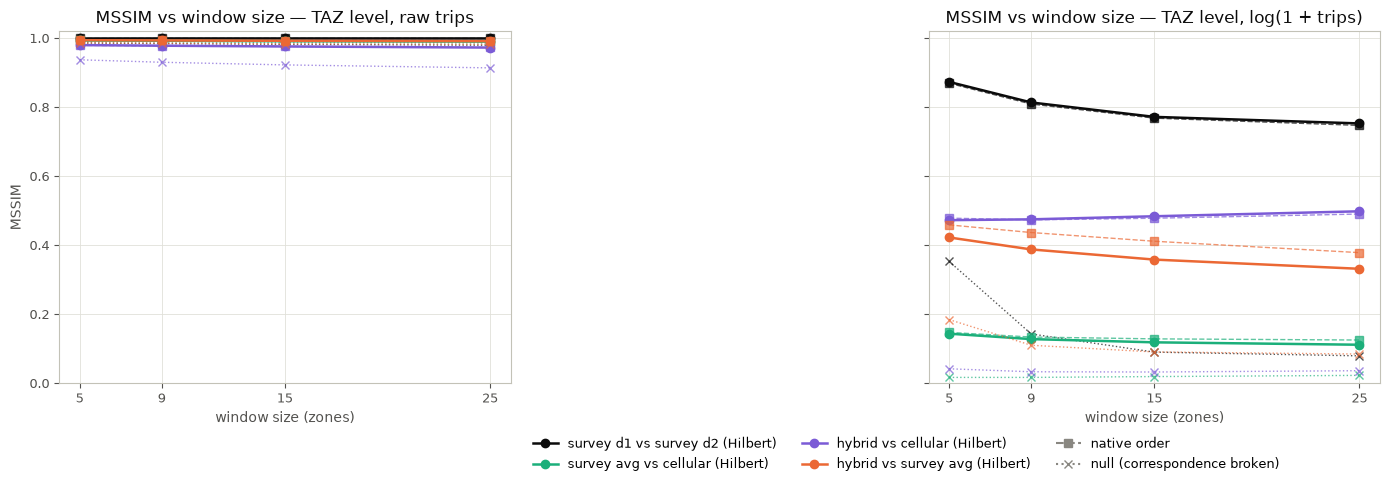

In [8]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5), facecolor='white', sharey=True)
for ax, tr in zip(axes, ['raw', 'log']):
    sub = res[(res['level'] == 'TAZ') & (res['scale'] == tr)]
    for p, color in zip(MAIN, [INK, AQUA, PURPLE, ORANGE]):
        h = sub[(sub['pair'] == p) & (sub['order'] == 'hilbert')].sort_values('window')
        n = sub[(sub['pair'] == p) & (sub['order'] == 'native')].sort_values('window')
        r = sub[(sub['pair'] == p) & (sub['order'] == 'null (B permuted)')].sort_values('window')
        ax.plot(h['window'], h['MSSIM'], color=color, marker='o', linewidth=1.8, label=f'{p} (Hilbert)')
        ax.plot(n['window'], n['MSSIM'], color=color, marker='s', linewidth=1, linestyle='--', alpha=0.7)
        ax.plot(r['window'], r['MSSIM'], color=color, marker='x', linewidth=1, linestyle=':', alpha=0.7)
    ax.plot([], [], color=MUTED, linestyle='--', marker='s', label='native order'); ax.plot([], [], color=MUTED, linestyle=':', marker='x', label='null (correspondence broken)')
    ax.set_xticks([5, 9, 15, 25]); ax.set_ylim(0, 1.02)
    style_ax(ax, f'MSSIM vs window size — TAZ level, {"raw trips" if tr == "raw" else "log(1 + trips)"}', 'window size (zones)', 'MSSIM' if tr == 'raw' else None)
    if tr == 'log':
        ax.legend(frameon=False, fontsize=9, loc='upper center', bbox_to_anchor=(-0.05, -0.12), ncol=3)
plt.tight_layout(); save_show(fig, 'mssim_window.png')

## M4. Where the matrices agree — local SSIM maps

Local SSIM at TAZ level (Hilbert order, window 9, log scale) for the three main pairs, then averaged into superzone blocks (mean of the windows whose centre cell belongs to that origin / destination superzone pair), per origin superzone, and by corridor class.

In [9]:
W, TR = 9, 'log'
o = ORD['hilbert']; h = W // 2
def local_map(a, b):
    A, B = reorder(SRC_TAZ[a], o), reorder(SRC_TAZ[b], o)
    return ssim_terms(np.log1p(A), np.log1p(B), W)['ssim']
MAPS = {p: local_map(*p.split(' vs ')) for p in MAIN}
sz_ord = sz_of[o][h:N - h]; corr_ord = corridor[o][h:N - h]
def block_means(m):
    tbl = pd.DataFrame(index=SZ, columns=SZ, dtype=float)
    for i, zi in enumerate(SZ):
        ri = sz_ord == zi
        for j, zj in enumerate(SZ):
            cj = sz_ord == zj
            tbl.iloc[i, j] = m[np.ix_(ri, cj)].mean() if ri.any() and cj.any() else np.nan
    return tbl
BLOCKS = {p: block_means(m) for p, m in MAPS.items()}
for p, t in BLOCKS.items():
    t.to_csv(f'{OUT}/mssim_sz_blocks_{p.replace(" ", "_")}.csv', float_format='%.4f')

# per origin superzone (mean over the rows of its TAZs), corridor flagged
per_o = pd.DataFrame({'origin SZ': SZ, 'corridor': [z in corr_sz for z in SZ]})
for p, m in MAPS.items():
    per_o[p] = [m[sz_ord == z].mean() for z in SZ]
per_o['survey trips'] = [SAVG[sz_of == z].sum() for z in SZ]
per_o.to_csv(f'{OUT}/mssim_by_origin_sz.csv', index=False, float_format='%.4f')

# corridor classes
cls = np.where(corr_ord[:, None] & corr_ord[None, :], 'corridor→corridor', np.where(corr_ord[:, None] & ~corr_ord[None, :], 'corridor→outside',
      np.where(~corr_ord[:, None] & corr_ord[None, :], 'outside→corridor', 'outside→outside')))
CLASSES = ['corridor→corridor', 'corridor→outside', 'outside→corridor', 'outside→outside']
cc = pd.DataFrame({p: {k: MAPS[p][cls == k].mean() for k in CLASSES} for p in MAIN})
diag_blocks = pd.DataFrame({p: {'intra-SZ blocks (mean)': float(np.nanmean(np.diag(BLOCKS[p].values))), 'inter-SZ blocks (mean)': float(np.nanmean(BLOCKS[p].values[~np.eye(len(SZ), dtype=bool)]))} for p in MAIN})
pd.concat([cc, diag_blocks]).to_csv(f'{OUT}/mssim_corridor_classes.csv', float_format='%.4f')
print(f"local SSIM (TAZ, Hilbert order, window {W}, log scale) — mean by corridor class and by superzone block type:")
pd.concat([cc, diag_blocks]).round(3)

local SSIM (TAZ, Hilbert order, window 9, log scale) — mean by corridor class and by superzone block type:


,survey d1 vs survey d2,survey avg vs cellular,hybrid vs cellular,hybrid vs survey avg
corridor→corridor,0.671,0.119,0.532,0.277
corridor→outside,0.802,0.113,0.436,0.396
outside→corridor,0.783,0.103,0.460,0.337
outside→outside,0.826,0.136,0.483,0.399
intra-SZ blocks (mean),0.770,0.247,0.759,0.346
inter-SZ blocks (mean),0.815,0.112,0.442,0.389


In [10]:
print("per origin superzone (mean local SSIM over its rows), sorted by survey vs cellular:")
print(per_o.sort_values('survey avg vs cellular')[['origin SZ', 'corridor', 'survey trips'] + MAIN].round(3).to_string(index=False))
w = per_o['survey trips'].values
print("\nflow-weighted means:", {p: round(float(np.average(per_o[p], weights=w)), 3) for p in MAIN})

per origin superzone (mean local SSIM over its rows), sorted by survey vs cellular:
 origin SZ  corridor  survey trips  survey d1 vs survey d2  survey avg vs cellular  hybrid vs cellular  hybrid vs survey avg
        19      True    132369.827                   0.842                   0.049               0.481                 0.218
        21      True     49740.518                   0.830                   0.052               0.498                 0.226
        20      True     30578.055                   0.850                   0.057               0.426                 0.287
        30     False     50689.214                   0.845                   0.060               0.455                 0.187
        11      True     26725.511                   0.777                   0.062               0.503                 0.177
        22     False     79153.923                   0.755                   0.068               0.539                 0.236
         3     False    106561.721       

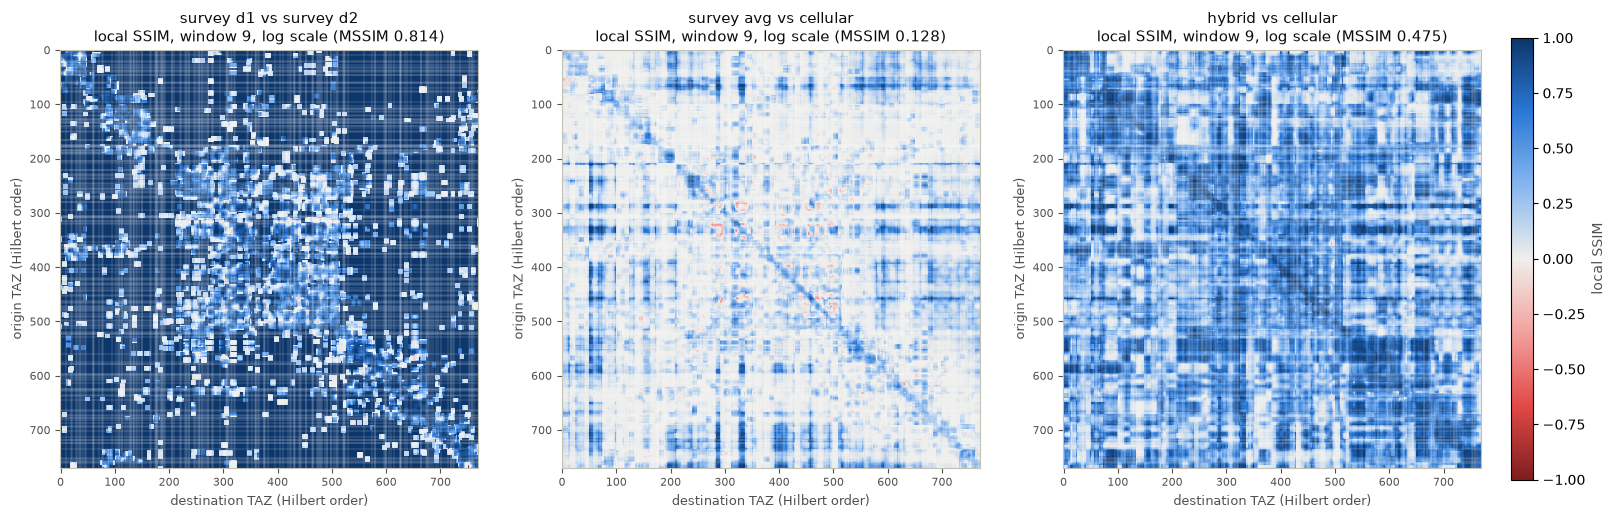

In [11]:
fig, axes = plt.subplots(1, 3, figsize=(19, 6.2), facecolor='white')
for ax, p in zip(axes, ['survey d1 vs survey d2', 'survey avg vs cellular', 'hybrid vs cellular']):
    im = ax.imshow(MAPS[p], cmap=CMAP_DIV, vmin=-1, vmax=1, interpolation='nearest')
    # superzone boundaries under the Hilbert order
    b = np.where(sz_ord[1:] != sz_ord[:-1])[0] + 0.5
    for x in b:
        ax.axhline(x, color='white', linewidth=0.25, alpha=0.6); ax.axvline(x, color='white', linewidth=0.25, alpha=0.6)
    ax.set_title(f'{p}\nlocal SSIM, window {W}, log scale (MSSIM {MAPS[p].mean():.3f})', color=INK, fontsize=11)
    ax.set_xlabel('destination TAZ (Hilbert order)', color=INK2, fontsize=9); ax.set_ylabel('origin TAZ (Hilbert order)', color=INK2, fontsize=9)
    ax.tick_params(colors=INK2, labelsize=8)
    for s in ax.spines.values(): s.set_color(AXIS)
fig.colorbar(im, ax=axes, fraction=0.015, pad=0.02).set_label('local SSIM', color=INK2)
save_show(fig, 'mssim_maps.png')

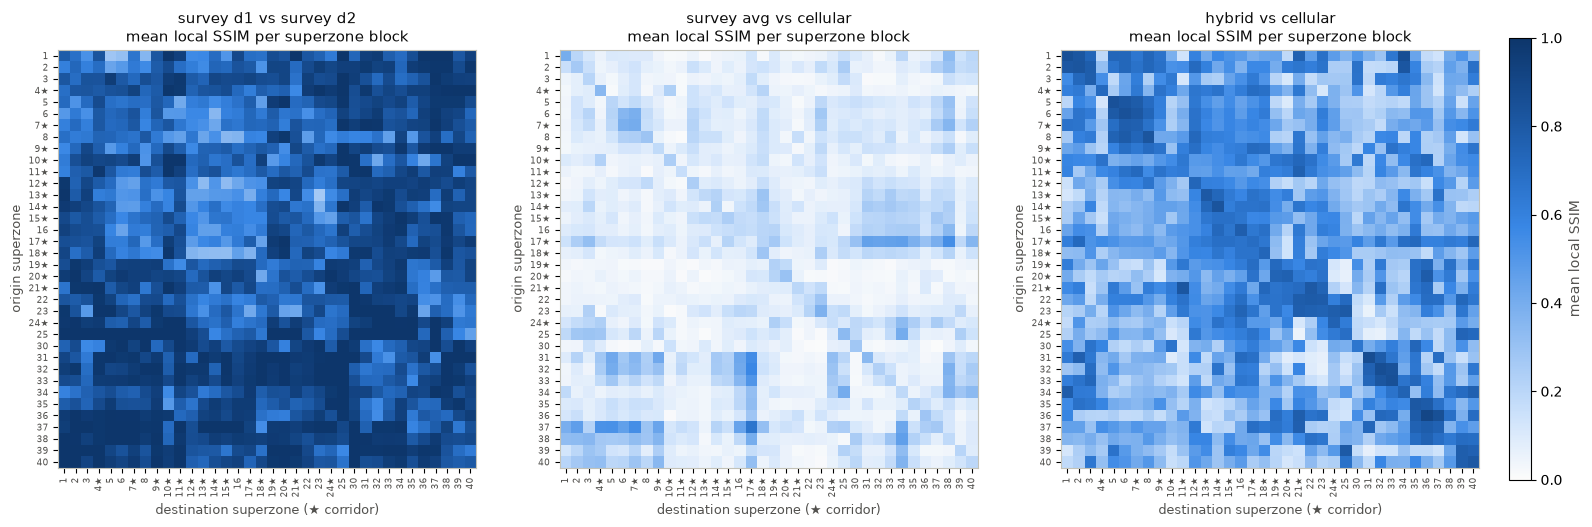

In [12]:
fig, axes = plt.subplots(1, 3, figsize=(19, 6.2), facecolor='white')
lab = [f"{z}{'★' if z in corr_sz else ''}" for z in SZ]
for ax, p in zip(axes, ['survey d1 vs survey d2', 'survey avg vs cellular', 'hybrid vs cellular']):
    t = BLOCKS[p].astype(float).values
    im = ax.imshow(t, cmap=CMAP_SEQ, vmin=0, vmax=1, interpolation='nearest')
    ax.set_xticks(range(len(SZ))); ax.set_xticklabels(lab, fontsize=6.5, rotation=90, color=INK2)
    ax.set_yticks(range(len(SZ))); ax.set_yticklabels(lab, fontsize=6.5, color=INK2)
    ax.set_title(f'{p}\nmean local SSIM per superzone block', color=INK, fontsize=11)
    ax.set_xlabel('destination superzone (★ corridor)', color=INK2, fontsize=9); ax.set_ylabel('origin superzone', color=INK2, fontsize=9)
    for s in ax.spines.values(): s.set_color(AXIS)
fig.colorbar(im, ax=axes, fraction=0.015, pad=0.02).set_label('mean local SSIM', color=INK2)
save_show(fig, 'mssim_sz_blocks.png')

## Summary

In [13]:
summ = res[res['pair'].isin(MAIN) & (res['order'] == 'hilbert')].pivot_table(index=['level', 'window', 'scale'], columns='pair', values='MSSIM')[MAIN]
summ = summ.loc[[('TAZ', 9, 'raw'), ('TAZ', 9, 'log'), ('TAZ', 25, 'log'), ('SZ', 3, 'raw'), ('SZ', 3, 'log'), ('AREA', 3, 'log')]]
null = res[res['pair'].isin(MAIN) & (res['order'] == 'null (B permuted)')].pivot_table(index=['level', 'window', 'scale'], columns='pair', values='MSSIM')[MAIN].loc[summ.index]
summ.columns = [f'{c}' for c in summ.columns]
for p in MAIN: summ[f'null: {p}'] = null[p]
summ.to_csv(f'{OUT}/mssim_headline.csv', float_format='%.4f')
print(f"outputs written to {OUT}/mssim_*.csv and Output/figures/mssim_*.png")
summ.round(3)

outputs written to Output/ths2017/tests/mssim_*.csv and Output/figures/mssim_*.png


survey d1 vs survey d2  survey avg vs cellular  \
level window scale                                                   
TAZ   9      raw                     0.999                   0.993   
             log                     0.814                   0.128   
      25     log                     0.753                   0.112   
SZ    3      raw                     0.994                   0.839   
             log                     0.686                   0.362   
AREA  3      log                     0.619                   0.257   

                    hybrid vs cellular  hybrid vs survey avg  \
level window scale                                             
TAZ   9      raw                 0.978                 0.994   
             log                 0.475                 0.388   
      25     log                 0.498                 0.332   
SZ    3      raw                 0.846                 1.000   
             log                 0.441                 0.938   
AREA  3      log                 0.678                 0.370   

                    null: survey d1 vs survey d2  \
level window scale                                 
TAZ   9      raw                           0.984   
             log                           0.143   
      25     log                           0.079   
SZ    3      raw                           0.773   
             log                           0.068   
AREA  3      log                           0.067   

                    null: survey avg vs cellular  null: hybrid vs cellular  \
level window scale                                                           
TAZ   9      raw                           0.989                     0.930   
             log                           0.017                     0.033   
      25     log                           0.023                     0.036   
SZ    3      raw                           0.592                     0.596   
             log                           0.090                     0.093   
AREA  3      log                           0.053                     0.081   

                    null: hybrid vs survey avg  
level window scale                              
TAZ   9      raw                         0.985  
             log                         0.110  
      25     log                         0.085  
SZ    3      raw                         0.772  
             log                         0.062  
AREA  3      log                         0.063

## Notes

- **Survey source.** Only the trips file (survey days 1 / 2) is read; the rebuilt day-average is asserted equal to the pipeline's saved matrix.
- **Scale.** SSIM's luminance term compares local means, so the cellular matrix is scaled to the survey total; the row-matched variant is reported as a sensitivity. On raw trips the index is dominated by the handful of very large (mostly intra-zonal) cells and the constants $C_1, C_2$ (set from the matrix maximum) swamp the small-cell windows, which is why the raw MSSIM is high for every pair, including random orderings; the log scale is the informative one for OD matrices whose cells span five orders of magnitude.
- **Ordering and chance.** Hilbert vs native ordering shows how little the result depends on the ordering choice. A random ordering applied to *both* matrices is not a chance level: it keeps every cell pair aligned and turns each window into a homogeneous mixture of the whole matrix, which pushes the luminance and contrast terms towards 1 — so it can score *above* the spatial ordering. The chance level is the broken-correspondence null (one matrix's zones permuted): the structure term then averages to ≈ 0 and MSSIM falls to what the value distributions alone give.
- **Below the cellular zone** both survey and cellular TAZ patterns are cellular allocation shares, so TAZ-level windows inside one cellular zone compare shared structure; superzone and sub-area levels are the fair comparison, as in the other test notebooks.